<a href="https://colab.research.google.com/github/UKD1211/Tier_N_Supplier_Visibility_Risk_Pred/blob/main/state_wise_risk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("/content/Unemployment_rate.csv")

In [3]:
df.drop(columns = ['Sl. No.', '2019-20', '2020-21'], inplace = True)

In [4]:
df

,State/UT,2021-22,2022-23,2023-24
0,Andhra Pradesh,4.2,4.1,4.1
1,Arunachal Pradesh,7.7,4.8,6.1
2,Assam,3.8,1.7,3.9
3,Bihar,6.0,3.9,3.0
4,Chhattisgarh,2.5,2.5,2.5
5,Delhi,5.3,1.9,2.1
6,Goa,12.0,9.7,8.5
7,Gujarat,2.0,1.7,1.1
8,Haryana,9.0,6.1,3.4
9,Himachal Pradesh,4.0,4.4,5.4


In [5]:
df['avg_unemployment_rate'] = (df['2021-22'] + df['2022-23'] + df['2023-24'])/3

In [6]:
df

,State/UT,2021-22,2022-23,2023-24,avg_unemployment_rate
0,Andhra Pradesh,4.2,4.1,4.1,4.133333
1,Arunachal Pradesh,7.7,4.8,6.1,6.200000
2,Assam,3.8,1.7,3.9,3.133333
3,Bihar,6.0,3.9,3.0,4.300000
4,Chhattisgarh,2.5,2.5,2.5,2.500000
5,Delhi,5.3,1.9,2.1,3.100000
6,Goa,12.0,9.7,8.5,10.066667
7,Gujarat,2.0,1.7,1.1,1.600000
8,Haryana,9.0,6.1,3.4,6.166667
9,Himachal Pradesh,4.0,4.4,5.4,4.600000


In [7]:
df_unemployment_rate = df[['State/UT', 'avg_unemployment_rate']]

In [8]:
df_unemployment_rate = df_unemployment_rate.iloc[0:37,:]

In [9]:
df_unemployment_rate = df_unemployment_rate.sort_values(by= 'State/UT').reset_index().drop(columns = ['index'])

In [10]:
#inflation

In [11]:
df_2 = pd.read_csv("/content/state_wise_inflation_rate.csv", header=1)

In [12]:
df_2

,Year,Month,State,Group,Sub Group,Description,Rural,Urban,Combined,Status,Unnamed: 10
0,2022,January,Andaman and Nicobar Islands,NaN,NaN,General Index (All Groups),8.32,6.26,7.36,F,NaN
1,2022,January,Andhra Pradesh,NaN,NaN,General Index (All Groups),4.69,5.78,5.12,F,NaN
2,2022,January,Arunachal Pradesh,NaN,NaN,General Index (All Groups),6.35,NaN,NaN,F,NaN
3,2022,January,Assam,NaN,NaN,General Index (All Groups),5.81,3.86,5.43,F,NaN
4,2022,January,Bihar,NaN,NaN,General Index (All Groups),5.60,6.21,5.71,F,NaN
...,...,...,...,...,...,...,...,...,...,...,...
1327,2025,January,Telangana,NaN,NaN,General Index (All Groups),2.34,2.15,2.22,F,NaN
1328,2025,January,Tripura,NaN,NaN,General Index (All Groups),2.44,3.57,2.71,F,NaN
1329,2025,January,Uttar Pradesh,NaN,NaN,General Index (All Groups),5.07,3.74,4.59,F,NaN
1330,2025,January,Uttarakhand,NaN,NaN,General Index (All Groups),4.37,5.67,4.90,F,NaN


In [13]:
df_2.drop(columns = ['Group','Sub Group', 'Rural', 'Urban', 'Status', 'Unnamed: 10','Description'], inplace = True)

In [14]:
df_2

,Year,Month,State,Combined
0,2022,January,Andaman and Nicobar Islands,7.36
1,2022,January,Andhra Pradesh,5.12
2,2022,January,Arunachal Pradesh,NaN
3,2022,January,Assam,5.43
4,2022,January,Bihar,5.71
...,...,...,...,...
1327,2025,January,Telangana,2.22
1328,2025,January,Tripura,2.71
1329,2025,January,Uttar Pradesh,4.59
1330,2025,January,Uttarakhand,4.90


In [15]:
df_2['State'].value_counts().shape

(36,)

In [16]:
df_2.groupby('State')['Combined'].mean().sort_values(ascending = False)

,Combined
State,
Haryana,6.639730
Telangana,6.552162
Uttar Pradesh,6.295405
Odisha,6.275405
Dadra and Nagar Haveli,6.226486
Rajasthan,6.096486
Bihar,6.024054
Andhra Pradesh,5.989730
Tripura,5.931351


In [17]:
df_inflation = df_2.groupby('State')['Combined'].mean().reset_index()

In [18]:
df_inflation

,State,Combined
0,Andaman and Nicobar Islands,4.388108
1,Andhra Pradesh,5.989730
2,Arunachal Pradesh,NaN
3,Assam,5.580270
4,Bihar,6.024054
5,Chandigarh,4.957297
6,Chhattisgarh,4.777297
7,Dadra and Nagar Haveli,6.226486
8,Daman and Diu,5.246757
9,Delhi,3.298108


In [19]:
df_inflation.rename(columns={'Combined': 'inflation_rate'}, inplace=True)

In [20]:
df_inflation

,State,inflation_rate
0,Andaman and Nicobar Islands,4.388108
1,Andhra Pradesh,5.989730
2,Arunachal Pradesh,NaN
3,Assam,5.580270
4,Bihar,6.024054
5,Chandigarh,4.957297
6,Chhattisgarh,4.777297
7,Dadra and Nagar Haveli,6.226486
8,Daman and Diu,5.246757
9,Delhi,3.298108


In [21]:
df_unemployment_rate.dropna(inplace = True)

In [22]:
df_unemployment_rate

,State/UT,avg_unemployment_rate
0,Andaman and Nicobar Islands,9.766667
1,Andhra Pradesh,4.133333
2,Arunachal Pradesh,6.200000
3,Assam,3.133333
4,Bihar,4.300000
5,Chandigarh,5.800000
6,Chhattisgarh,2.500000
7,Dadra and Nagar Haveli,3.333333
9,Delhi,3.100000
10,Goa,10.066667


In [23]:
#poverty_index

In [24]:
df_3 = pd.read_excel("/content/poverty_index.XLSX")

In [25]:
df_3

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7
0,NaN,TABLE 10: STATE-WISE POVERTY ESTIMATES - MULTI...,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,State/Union Territory,NFHS-4 (2015-16),NaN,NaN,NFHS-5 (2019-21),NaN,NaN
2,NaN,NaN,Headcount Ratio (Per cent),Intensity (Per cent),MPI,Headcount Ratio (Per cent),Intensity (Per cent),MPI
3,NaN,Andhra Pradesh,11.77,43.28,0.05,6.06,41.12,0.03
4,NaN,Arunachal Pradesh,24.23,47.25,0.12,13.76,43.04,0.06
5,NaN,Assam,32.65,47.88,0.16,19.35,44.41,0.09
6,NaN,Bihar,51.89,51.01,0.27,33.76,47.4,0.16
7,NaN,Chhattisgarh,29.9,44.64,0.13,16.37,42.61,0.07
8,NaN,Goa,3.76,40.13,0.02,0.84,38.69,0
9,NaN,Gujarat,18.47,44.97,0.08,11.66,43.25,0.05


In [26]:
df_3 = df_3.iloc[3:].reset_index(drop=True)

In [27]:
df_3

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7
0,NaN,Andhra Pradesh,11.77,43.28,0.05,6.06,41.12,0.03
1,NaN,Arunachal Pradesh,24.23,47.25,0.12,13.76,43.04,0.06
2,NaN,Assam,32.65,47.88,0.16,19.35,44.41,0.09
3,NaN,Bihar,51.89,51.01,0.27,33.76,47.4,0.16
4,NaN,Chhattisgarh,29.9,44.64,0.13,16.37,42.61,0.07
5,NaN,Goa,3.76,40.13,0.02,0.84,38.69,0
6,NaN,Gujarat,18.47,44.97,0.08,11.66,43.25,0.05
7,NaN,Haryana,11.88,44.4,0.05,7.07,43.34,0.03
8,NaN,Himachal Pradesh,7.59,39.44,0.03,4.93,40.22,0.02
9,NaN,Jharkhand,42.1,47.92,0.2,28.81,45.59,0.13


In [28]:
df_3.columns = [
    "drop",
    "State",
    "NFHS4_headcount",
    "NFHS4_intensity",
    "NFHS4_MPI",
    "NFHS5_headcount",
    "NFHS5_intensity",
    "NFHS5_MPI"
]

In [29]:
df_3 = df_3[["State", "NFHS5_MPI"]]

In [30]:
df_3["State"] = df_3["State"].str.strip()

/tmp/ipykernel_10919/1167422776.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_3["State"] = df_3["State"].str.strip()


In [31]:
df_3["NFHS5_MPI"] = pd.to_numeric(df_3["NFHS5_MPI"], errors="coerce")

/tmp/ipykernel_10919/2043118937.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_3["NFHS5_MPI"] = pd.to_numeric(df_3["NFHS5_MPI"], errors="coerce")


In [32]:
df_3 = df_3.dropna()

In [33]:
df_3.rename(columns={"NFHS5_MPI": "poverty_rate"}, inplace=True)

In [34]:
df_3 = df_3.sort_values(by="State").reset_index(drop=True)

In [35]:
df_poverty_rate = df_3[1:].reset_index(drop = True)

In [36]:
df_poverty_rate

,State,poverty_rate
0,Andaman & Nicobar Islands,0.01
1,Andhra Pradesh,0.03
2,Arunachal Pradesh,0.06
3,Assam,0.09
4,Bihar,0.16
5,Chandigarh,0.02
6,Chhattisgarh,0.07
7,Dadra & Nagar Haveli & Daman & Diu,0.04
8,Delhi,0.01
9,Goa,0.00


In [37]:
#per_capita_income

In [38]:
df_4 = pd.read_excel("/content/per_capita_income.xlsx")

In [39]:
df_4

,TABLE 19: PER CAPITA NET STATE DOMESTIC PRODUCT (Current Prices) (Concld.),Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8
0,(₹),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,State/Union Territory,Base: 2011-12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,2017-18,2018-19,2019-20,2020-21,2021-22,2022-23,2023-24,2024-25
3,Andaman & Nicobar Islands,178709,204254,219653,205368,229570,263984,276000,-
4,Andhra Pradesh,138299,154031,160341,168063,193703,219917,237951,266240
5,Arunachal Pradesh,138836,155103,182171,181537,190851,204469,217325,246813
6,Assam,75151,81034,90123,86947,103371,121573,143852,159185
7,Bihar,36850,40715,44175,42128,47296,54637,62201,69321
8,Chandigarh,280512,307812,330703,290417,337406,408512,453457,-
9,Chhattisgarh,88793,102024,106611,106117,123493,134996,148922,162870


In [40]:
df_4 = df_4.iloc[3:].reset_index(drop=True)

In [41]:
df_4.columns = [
    "State",
    "2017",
    "2018",
    "2019",
    "2020",
    "2021",
    "2022",
    "2023",
    "2024"
]

In [42]:
df_4["State"] = df_4["State"].str.strip()

In [43]:
for col in df_4.columns[1:]:
    df_4[col] = pd.to_numeric(df_4[col], errors="coerce")

In [44]:
df_4["per_capita_income"] = df_4[["2021", "2022", "2023"]].mean(axis=1)

In [45]:
df_4 = df_4[["State", "per_capita_income"]]

In [46]:
df_4 = df_4.dropna()

In [47]:
df_4 = df_4.sort_values(by="State").reset_index(drop=True)

In [48]:
df_per_capita_income = df_4

In [49]:
df_per_capita_income

,State,per_capita_income
0,Andaman & Nicobar Islands,256518.000000
1,Andhra Pradesh,217190.333333
2,Arunachal Pradesh,204215.000000
3,Assam,122932.000000
4,Bihar,54711.333333
5,Chandigarh,399791.666667
6,Chhattisgarh,135803.666667
7,Delhi,415816.333333
8,Goa,525967.000000
9,Gujarat,257017.500000


In [50]:
df_unemp = df_unemployment_rate.merge(df_per_capita_income, left_on="State/UT", right_on="State", how="left") \
                               .drop(columns=["State"])

In [51]:
df_unemp.rename(columns={"State/UT": "State"}, inplace=True)
df_unemp

,State,avg_unemployment_rate,per_capita_income
0,Andaman and Nicobar Islands,9.766667,NaN
1,Andhra Pradesh,4.133333,217190.333333
2,Arunachal Pradesh,6.200000,204215.000000
3,Assam,3.133333,122932.000000
4,Bihar,4.300000,54711.333333
5,Chandigarh,5.800000,399791.666667
6,Chhattisgarh,2.500000,135803.666667
7,Dadra and Nagar Haveli,3.333333,NaN
8,Delhi,3.100000,415816.333333
9,Goa,10.066667,525967.000000


In [52]:
set(df_unemployment_rate["State/UT"]) - set(df_per_capita_income["State"])

{'Andaman and Nicobar Islands',
 'Dadra and Nagar Haveli',
 'Jammu and Kashmir',
 'Lakshadweep'}

In [53]:
state_map = {
    "Andaman and Nicobar Islands": "Andaman & Nicobar Islands",
    "Dadra and Nagar Haveli": "Dadra and Nagar Haveli and Daman and Diu",
    "Delhi": "Delhi",
    "Jammu & Kashmir": "Jammu and Kashmir"
}

df_unemployment_rate["State/UT"] = df_unemployment_rate["State/UT"].replace(state_map)

In [54]:
df_unemp = df_unemployment_rate.merge(
    df_per_capita_income,
    left_on="State/UT",
    right_on="State",
    how="left"
).drop(columns=["State"])

df_unemp.rename(columns={"State/UT": "State"}, inplace=True)

In [55]:
df_unemp["per_capita_income"].fillna(df_unemp["per_capita_income"].mean(), inplace=True)

/tmp/ipykernel_10919/2604215634.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_unemp["per_capita_income"].fillna(df_unemp["per_capita_income"].mean(), inplace=True)


In [56]:
df_unemp

,State,avg_unemployment_rate,per_capita_income
0,Andaman & Nicobar Islands,9.766667,256518.000000
1,Andhra Pradesh,4.133333,217190.333333
2,Arunachal Pradesh,6.200000,204215.000000
3,Assam,3.133333,122932.000000
4,Bihar,4.300000,54711.333333
5,Chandigarh,5.800000,399791.666667
6,Chhattisgarh,2.500000,135803.666667
7,Dadra and Nagar Haveli and Daman and Diu,3.333333,223005.196970
8,Delhi,3.100000,415816.333333
9,Goa,10.066667,525967.000000


In [57]:
for df in [df_unemployment_rate, df_per_capita_income]:
    df.iloc[:, 0] = df.iloc[:, 0].str.strip()

In [58]:
df_final = df_unemp.merge(df_inflation, left_on="State", right_on="State", how="left").merge(df_poverty_rate, left_on="State", right_on="State", how="left")

In [59]:
df_final

,State,avg_unemployment_rate,per_capita_income,inflation_rate,poverty_rate
0,Andaman & Nicobar Islands,9.766667,256518.000000,NaN,0.01
1,Andhra Pradesh,4.133333,217190.333333,5.989730,0.03
2,Arunachal Pradesh,6.200000,204215.000000,NaN,0.06
3,Assam,3.133333,122932.000000,5.580270,0.09
4,Bihar,4.300000,54711.333333,6.024054,0.16
5,Chandigarh,5.800000,399791.666667,4.957297,0.02
6,Chhattisgarh,2.500000,135803.666667,4.777297,0.07
7,Dadra and Nagar Haveli and Daman and Diu,3.333333,223005.196970,NaN,NaN
8,Delhi,3.100000,415816.333333,3.298108,0.01
9,Goa,10.066667,525967.000000,3.192162,0.00


In [60]:
df_final.isnull().mean()

,0
State,0.000000
avg_unemployment_rate,0.000000
per_capita_income,0.000000
inflation_rate,0.111111
poverty_rate,0.055556


In [61]:
set(df_unemp["State"]) - set(df_inflation["State"])

{'Andaman & Nicobar Islands',
 'Dadra and Nagar Haveli and Daman and Diu',
 'Ladakh'}

In [62]:
state_map = {
    "Andaman & Nicobar Islands": "Andaman and Nicobar Islands",
    "Dadra and Nagar Haveli and Daman and Diu": "Dadra and Nagar Haveli",
}

for df in [df_inflation, df_poverty_rate]:
    df["State"] = df["State"].replace(state_map)

In [63]:
for col in ["inflation_rate", "poverty_rate", "per_capita_income"]:
    df_final[col].fillna(df_final[col].median(), inplace=True)

/tmp/ipykernel_10919/1558809023.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_final[col].fillna(df_final[col].median(), inplace=True)


In [64]:
df_final

,State,avg_unemployment_rate,per_capita_income,inflation_rate,poverty_rate
0,Andaman & Nicobar Islands,9.766667,256518.000000,5.480946,0.01
1,Andhra Pradesh,4.133333,217190.333333,5.989730,0.03
2,Arunachal Pradesh,6.200000,204215.000000,5.480946,0.06
3,Assam,3.133333,122932.000000,5.580270,0.09
4,Bihar,4.300000,54711.333333,6.024054,0.16
5,Chandigarh,5.800000,399791.666667,4.957297,0.02
6,Chhattisgarh,2.500000,135803.666667,4.777297,0.07
7,Dadra and Nagar Haveli and Daman and Diu,3.333333,223005.196970,5.480946,0.03
8,Delhi,3.100000,415816.333333,3.298108,0.01
9,Goa,10.066667,525967.000000,3.192162,0.00


In [65]:
#applying the PCA

In [66]:
from sklearn.preprocessing import StandardScaler
std = StandardScaler()

In [67]:
std.fit_transform(df_final[["avg_unemployment_rate", "per_capita_income", "inflation_rate", "poverty_rate"]])

array([[ 1.99378712,  0.30908652,  0.1527502 , -0.8796058 ],
       [-0.24549677, -0.05363013,  0.81590722, -0.37295286],
       [ 0.57601566, -0.17330083,  0.1527502 ,  0.38702655],
       [-0.64300279, -0.92296895,  0.28221113,  1.14700596],
       [-0.17924577, -1.55216397,  0.8606461 ,  2.92029126],
       [ 0.41701326,  1.63049076, -0.52978193, -0.62627933],
       [-0.8947566 , -0.80425436, -0.76439684,  0.64035302],
       [-0.56350158,  0.        ,  0.1527502 , -0.37295286],
       [-0.65625299,  1.77828527, -2.69239598, -0.8796058 ],
       [ 2.11303893,  2.79419811, -2.83048764, -1.13293227],
       [-1.25251201,  0.31369338,  0.70282706,  0.13370008],
       [ 0.56276546,  0.62938381,  1.66312775, -0.37295286],
       [-0.05999396, -0.08093618, -0.78835152, -0.62627933],
       [ 0.19175985,  0.        , -0.20568925, -0.37295286],
       [-1.22601161, -1.16254401,  0.19625612,  2.16031184],
       [-0.78875499,  0.76884079,  0.14940359, -0.37295286],
       [ 1.26502609,  0.

In [68]:
X_scaled = pd.DataFrame(std.fit_transform(df_final[["avg_unemployment_rate", "per_capita_income", "inflation_rate", "poverty_rate"]]), columns = ["avg_unemployment_rate", "per_capita_income", "inflation_rate", "poverty_rate"])

In [69]:
X_scaled

,avg_unemployment_rate,per_capita_income,inflation_rate,poverty_rate
0,1.993787,0.309087,0.152750,-0.879606
1,-0.245497,-0.053630,0.815907,-0.372953
2,0.576016,-0.173301,0.152750,0.387027
3,-0.643003,-0.922969,0.282211,1.147006
4,-0.179246,-1.552164,0.860646,2.920291
5,0.417013,1.630491,-0.529782,-0.626279
6,-0.894757,-0.804254,-0.764397,0.640353
7,-0.563502,0.000000,0.152750,-0.372953
8,-0.656253,1.778285,-2.692396,-0.879606
9,2.113039,2.794198,-2.830488,-1.132932


In [70]:
X_scaled["per_capita_income"] = -X_scaled["per_capita_income"]

In [71]:
X_scaled

,avg_unemployment_rate,per_capita_income,inflation_rate,poverty_rate
0,1.993787,-0.309087,0.152750,-0.879606
1,-0.245497,0.053630,0.815907,-0.372953
2,0.576016,0.173301,0.152750,0.387027
3,-0.643003,0.922969,0.282211,1.147006
4,-0.179246,1.552164,0.860646,2.920291
5,0.417013,-1.630491,-0.529782,-0.626279
6,-0.894757,0.804254,-0.764397,0.640353
7,-0.563502,-0.000000,0.152750,-0.372953
8,-0.656253,-1.778285,-2.692396,-0.879606
9,2.113039,-2.794198,-2.830488,-1.132932


In [72]:
cov_matrix = np.cov(X_scaled, rowvar=False)

In [73]:
cov_matrix

array([[ 1.02857143, -0.21169461, -0.3403011 , -0.42657662],
       [-0.21169461,  1.02857143,  0.47903017,  0.71113521],
       [-0.3403011 ,  0.47903017,  1.02857143,  0.24757069],
       [-0.42657662,  0.71113521,  0.24757069,  1.02857143]])

In [74]:
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

In [75]:
print(eigenvalues)
print(eigenvectors)

[0.21217962 0.78487099 0.85493448 2.26230062]
[[ 0.28791979 -0.42988577  0.74957525 -0.4128406 ]
 [-0.65408712 -0.13950329  0.48266923  0.56545494]
 [ 0.3143151  -0.77492941 -0.31983982  0.4454132 ]
 [ 0.62488259  0.44183873  0.3207333   0.55805952]]


In [76]:
idx = np.argsort(eigenvalues)[::-1]

eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

In [77]:
print(eigenvalues)
print(eigenvectors)

[2.26230062 0.85493448 0.78487099 0.21217962]
[[-0.4128406   0.74957525 -0.42988577  0.28791979]
 [ 0.56545494  0.48266923 -0.13950329 -0.65408712]
 [ 0.4454132  -0.31983982 -0.77492941  0.3143151 ]
 [ 0.55805952  0.3207333   0.44183873  0.62488259]]


In [78]:
pc1 = eigenvectors[:,0]

In [79]:
state_risk = X_scaled.dot(pc1)

In [80]:
state_risk

,0
0,-1.420726
1,0.286962
2,0.144212
3,1.553153
4,2.964718
5,-1.679602
6,0.841044
7,0.092543
8,-2.424713
9,-4.345322


In [81]:
def normal(a):
 return (a - state_risk.min()) / (state_risk.max() - state_risk.min())

state_risk = state_risk.apply(normal)

In [82]:
df_final['state_risk_cal'] = state_risk

In [83]:
df_final

,State,avg_unemployment_rate,per_capita_income,inflation_rate,poverty_rate,state_risk_cal
0,Andaman & Nicobar Islands,9.766667,256518.000000,5.480946,0.01,0.400079
1,Andhra Pradesh,4.133333,217190.333333,5.989730,0.03,0.633688
2,Arunachal Pradesh,6.200000,204215.000000,5.480946,0.06,0.614160
3,Assam,3.133333,122932.000000,5.580270,0.09,0.806901
4,Bihar,4.300000,54711.333333,6.024054,0.16,1.000000
5,Chandigarh,5.800000,399791.666667,4.957297,0.02,0.364666
6,Chhattisgarh,2.500000,135803.666667,4.777297,0.07,0.709485
7,Dadra and Nagar Haveli and Daman and Diu,3.333333,223005.196970,5.480946,0.03,0.607092
8,Delhi,3.100000,415816.333333,3.298108,0.01,0.262736
9,Goa,10.066667,525967.000000,3.192162,0.00,0.000000


In [84]:
df_final.sort_values(by = 'state_risk_cal' , ascending = False)

,State,avg_unemployment_rate,per_capita_income,inflation_rate,poverty_rate,state_risk_cal
4,Bihar,4.300000,54711.333333,6.024054,0.16,1.000000
14,Jharkhand,1.666667,96956.000000,5.514324,0.13,0.930478
33,Uttar Pradesh,2.766667,86022.333333,6.295405,0.10,0.917599
19,Madhya Pradesh,1.533333,128354.000000,5.776216,0.09,0.854513
3,Assam,3.133333,122932.000000,5.580270,0.09,0.806901
25,Odisha,4.333333,139598.000000,6.275405,0.07,0.784600
32,Tripura,2.133333,154305.000000,5.931351,0.06,0.776832
28,Rajasthan,4.433333,150270.000000,6.096486,0.07,0.760532
22,Meghalaya,4.933333,124613.000000,4.069189,0.13,0.722640
35,West Bengal,2.766667,136769.000000,5.483514,0.05,0.720219


In [85]:
import seaborn as sns

<Axes: xlabel='State', ylabel='state_risk_cal'>

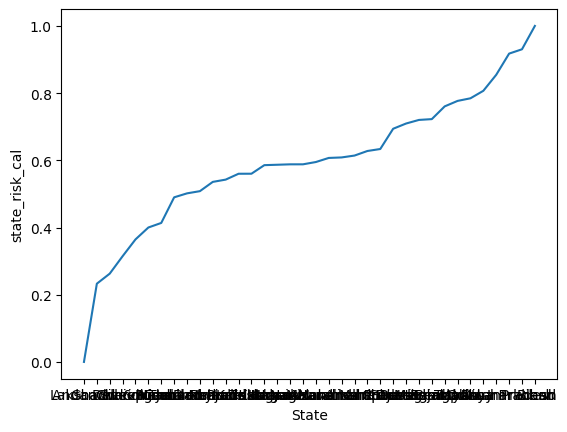

In [86]:
sns.lineplot(data = df_final.sort_values(by = 'state_risk_cal') , x = 'State', y = 'state_risk_cal')

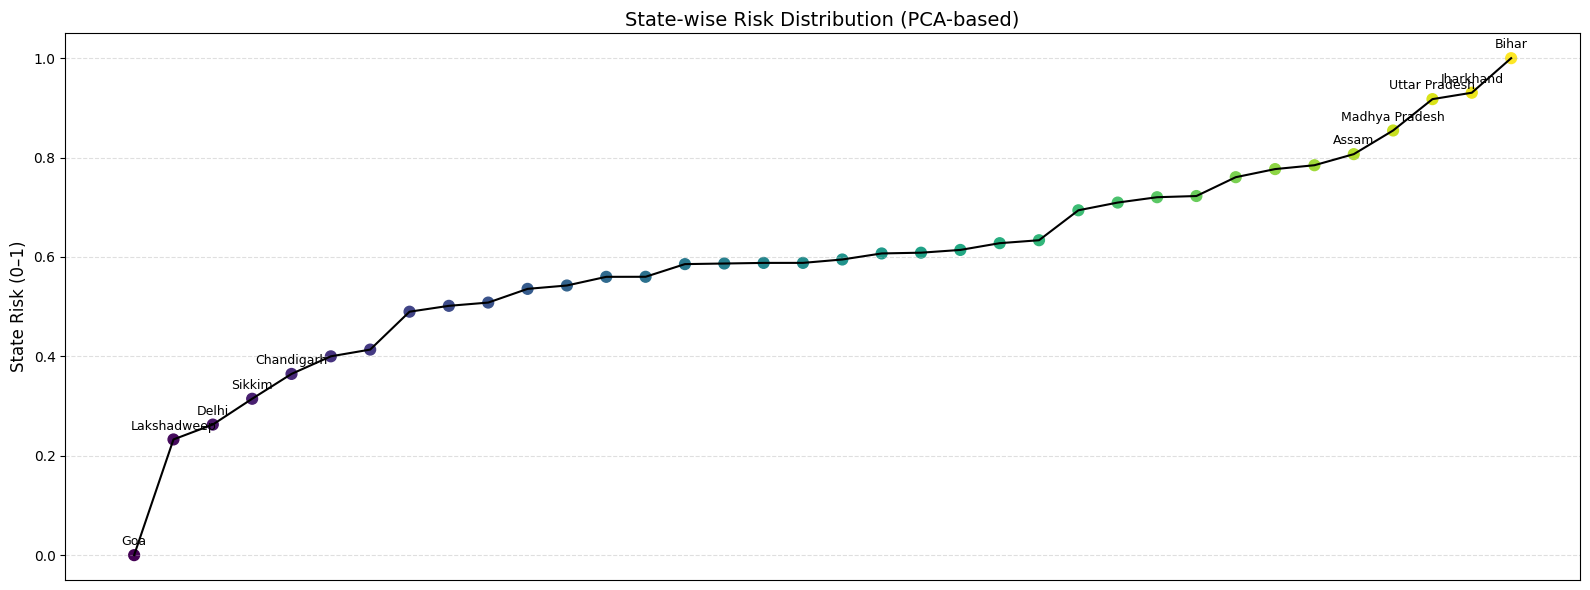

In [87]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Sort data
df_plot = df_final.sort_values(by="state_risk_cal").reset_index(drop=True)

plt.figure(figsize=(16,6))

# Color gradient
colors = plt.cm.viridis(np.linspace(0, 1, len(df_plot)))

# Line + scatter
plt.plot(df_plot["state_risk_cal"], color="black", linewidth=1.5)
plt.scatter(range(len(df_plot)), df_plot["state_risk_cal"], c=colors, s=60)

# Labels only for top 5 and bottom 5 (clean!)
for i in list(range(5)) + list(range(len(df_plot)-5, len(df_plot))):
    plt.text(i, df_plot["state_risk_cal"][i] + 0.02,
             df_plot["State"][i],
             fontsize=9, ha='center')

# Axis formatting
plt.xticks([])  # remove clutter
plt.ylabel("State Risk (0–1)", fontsize=12)
plt.title("State-wise Risk Distribution (PCA-based)", fontsize=14)

# Grid for readability
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

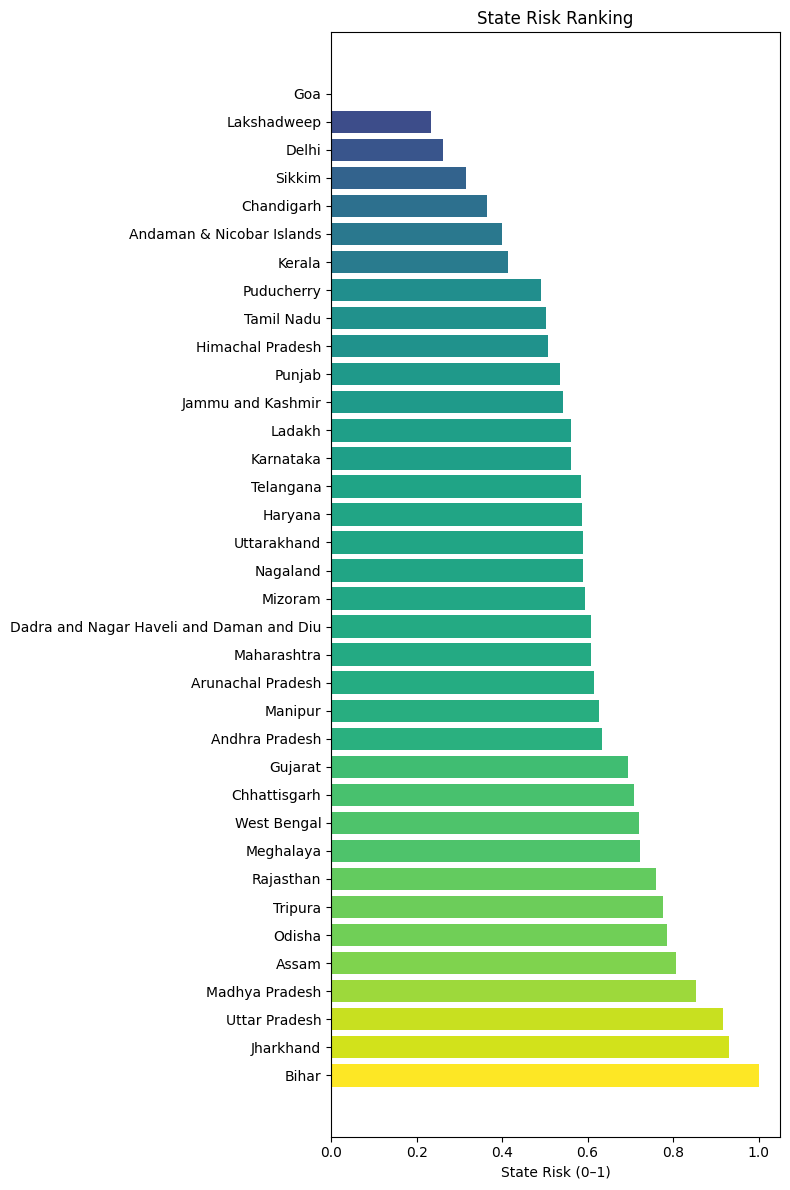

In [88]:
plt.figure(figsize=(8,12))

df_plot_rev = df_plot[::-1]

plt.barh(df_plot_rev["State"], df_plot_rev["state_risk_cal"],
         color=plt.cm.viridis(df_plot_rev["state_risk_cal"]))

plt.xlabel("State Risk (0–1)")
plt.title("State Risk Ranking")

plt.tight_layout()
plt.show()

In [90]:
df_final.to_excel("output.xlsx", index=False)